# Optimizing Delta V for Earth to Moon Orbits

- This Notebook is used to run an instance of the CR3BPSytsem class

In [ ]:
import numpy as np
np.set_printoptions(precision=2, suppress=False)
import matplotlib.pyplot as plt
from cr3bp import create_earth_moon_system, plot_trajectory, circular_orbit_state_earth
from cr3bp.leo_lmo_optimizer import LEOtoLMOProblem
%matplotlib inline

In [31]:
em = create_earth_moon_system()

In [42]:
best_x0 = np.array([ 4.08407045,  2.44244324, -1.76960599, -0.        ,  0.79032258])

theta = best_x0[0]
delta_v = best_x0[1:4]
tof = best_x0[4]
print(delta_v)

[ 2.44 -1.77 -0.  ]


In [43]:
state0_inertial = circular_orbit_state_earth(theta, 400000)
state0_rotating = em.inertial_to_rotating(state0_inertial,0)

state0_rotating[3:] += delta_v
state0 = state0_rotating
print(state0)

[-0.02 -0.01 -0.    8.49 -6.15 -0.  ]


In [44]:
time = (0,tof)
t_eval = np.linspace(time[0],time[1],1000)

In [45]:
states, times, stm_final, sol = em.solve_with_stm(state0, time, t_eval=t_eval)

### Plots

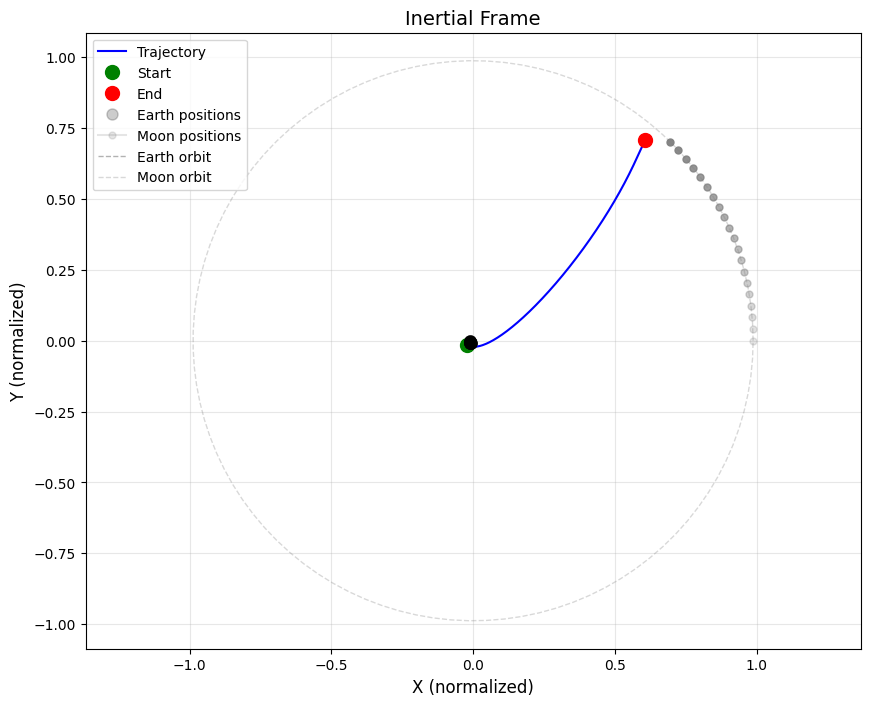

In [46]:
plot_trajectory(states, em.mu, t_eval, frame="Inertial")

In [ ]:
problem = LEOtoLMOProblem(
    mu=em.mu,
    leo_alt_m=463e3,   # 463 km LEO
    lmo_alt_m=100e3,   # 100 km LMO
    print_iter=False
)